In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv(r"D:\Study\Data Analysi_NTI\final project\dataset\bike_sales_cleaned.csv")

In [41]:
# ============================================================
# 2. BASIC EDA
# ============================================================
print("Shape:", df.shape)
print("\n", df.head())
print("\nData Types:\n", df.dtypes)
print("\nDescribe:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Shape: (100000, 21)

    Sale_ID        Date  Year  Month Month_Name Quarter  Season Day_of_Week  \
0        1  2022-07-11  2022      7       July      Q3  Summer      Monday   
1        2  2024-05-03  2024      5        May      Q2  Spring      Friday   
2        3  2022-09-01  2022      9  September      Q3    Fall    Thursday   
3        4  2022-09-28  2022      9  September      Q3    Fall   Wednesday   
4        5  2021-01-05  2021      1    January      Q1  Winter     Tuesday   

   Customer_ID  Customer_Age  ... Age_Group     Bike_Model    Price  Quantity  \
0         9390            70  ...    Senior        Cruiser   318.32         1   
1         3374            18  ...     Youth    Hybrid Bike  3093.47         4   
2         2689            27  ...     Adult   Folding Bike  4247.99         3   
3         3797            19  ...     Youth  Mountain Bike  1722.01         3   
4         1633            20  ...     Youth            BMX  3941.44         3   

   Total_Revenue  Reve

In [ ]:
# ============================================================
# 3. DATE CONVERSION
# ============================================================
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [10]:
# ============================================================
# 4. FEATURE ENGINEERING
# ============================================================
df['Total_Revenue'] = df['Price'] * df['Quantity']
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Month_Name'] = df['Date'].dt.strftime('%B')
df['Day_of_Week'] = df['Date'].dt.strftime('%A')
df['Age_Group'] = pd.cut(df['Customer_Age'], 
                          bins=[0, 25, 40, 60, 100], 
                          labels=['Youth', 'Adult', 'Middle Age', 'Senior'])

print(df[['Date', 'Total_Revenue', 'Year', 'Month', 'Age_Group']].head())

        Date  Total_Revenue  Year  Month   Age_Group
0 2022-07-11         318.32  2022      7      Senior
1 2024-05-03       12373.88  2024      5       Adult
2 2022-09-01       12743.97  2022      9  Middle Age
3 2022-09-28        5166.03  2022      9       Youth
4 2021-01-05       11824.32  2021      1      Senior


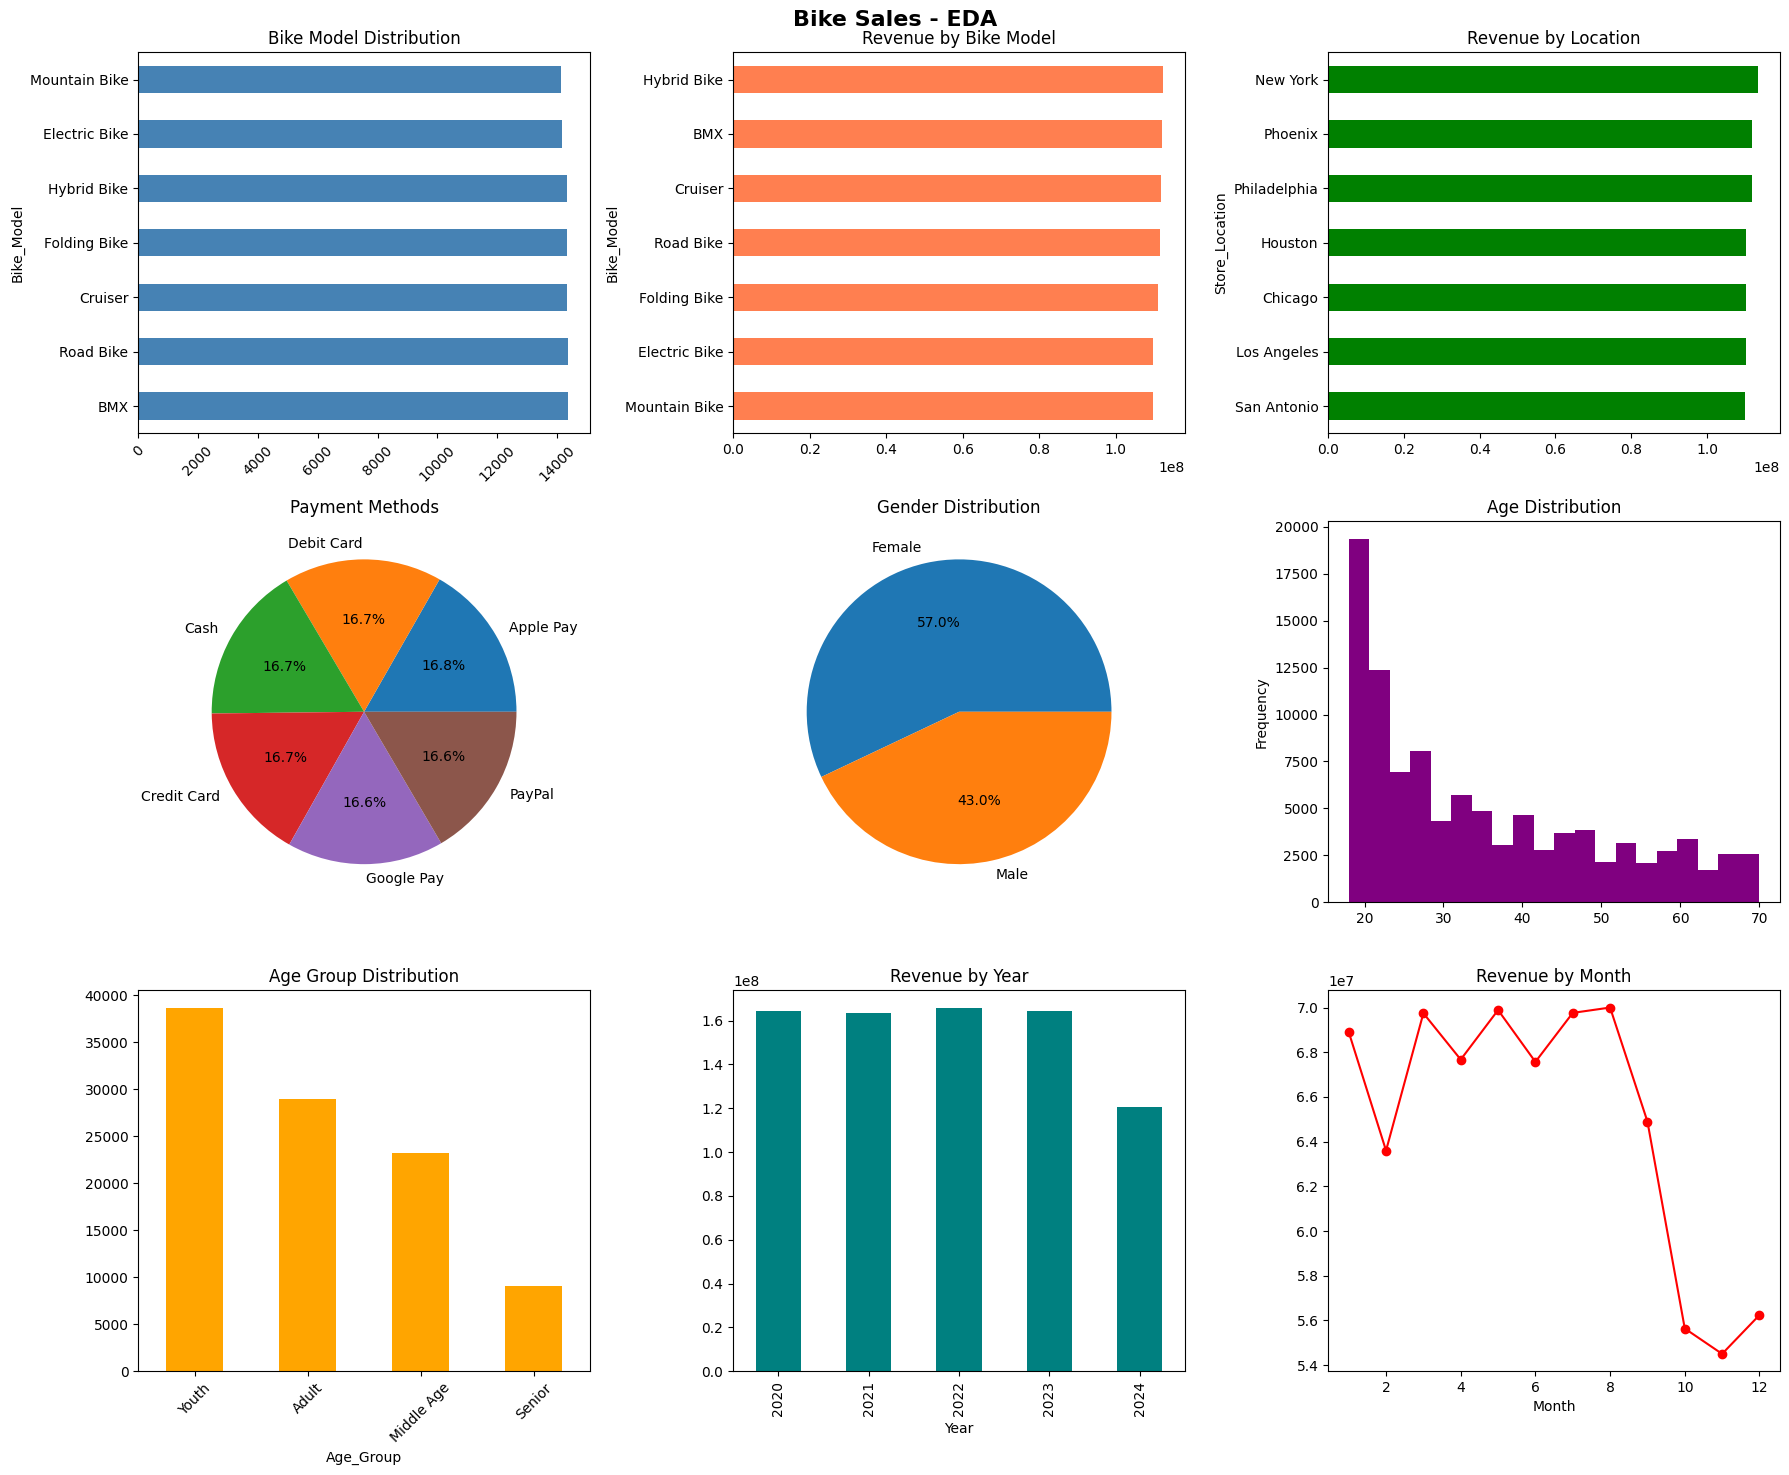

In [42]:
# ============================================================
# 5. EDA VISUALIZATIONS
# ============================================================
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('Bike Sales - EDA', fontsize=16, fontweight='bold')

# 1. Bike Model Distribution
df['Bike_Model'].value_counts().plot(kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Bike Model Distribution')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Revenue by Bike Model
df.groupby('Bike_Model')['Total_Revenue'].sum().sort_values().plot(kind='barh', ax=axes[0,1], color='coral')
axes[0,1].set_title('Revenue by Bike Model')

# 3. Revenue by Location
df.groupby('Store_Location')['Total_Revenue'].sum().sort_values().plot(kind='barh', ax=axes[0,2], color='green')
axes[0,2].set_title('Revenue by Location')

# 4. Payment Method
df['Payment_Method'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%')
axes[1,0].set_title('Payment Methods')

# 5. Gender Distribution
df['Customer_Gender'].value_counts().plot(kind='pie', ax=axes[1,1], autopct='%1.1f%%')
axes[1,1].set_title('Gender Distribution')

# 6. Age Distribution
df['Customer_Age'].plot(kind='hist', ax=axes[1,2], bins=20, color='purple')
axes[1,2].set_title('Age Distribution')

# 7. Age Group
df['Age_Group'].value_counts().plot(kind='bar', ax=axes[2,0], color='orange')
axes[2,0].set_title('Age Group Distribution')
axes[2,0].tick_params(axis='x', rotation=45)

# 8. Yearly Revenue
df.groupby('Year')['Total_Revenue'].sum().plot(kind='bar', ax=axes[2,1], color='teal')
axes[2,1].set_title('Revenue by Year')

# 9. Monthly Revenue
df.groupby('Month')['Total_Revenue'].sum().plot(kind='line', ax=axes[2,2], color='red', marker='o')
axes[2,2].set_title('Revenue by Month')

plt.tight_layout()
plt.show()

In [43]:
print("Duplicates :", df.duplicated().sum())
print("\nMissing Values :\n", df.isnull().sum())


Duplicates : 0

Missing Values :
 Sale_ID             0
Date                0
Year                0
Month               0
Month_Name          0
Quarter             0
Season              0
Day_of_Week         0
Customer_ID         0
Customer_Age        0
Customer_Gender     0
Age_Group           0
Bike_Model          0
Price               0
Quantity            0
Total_Revenue       0
Revenue_Category    0
Store_Location      0
Salesperson_ID      0
Salesperson_Name    0
Payment_Method      0
dtype: int64


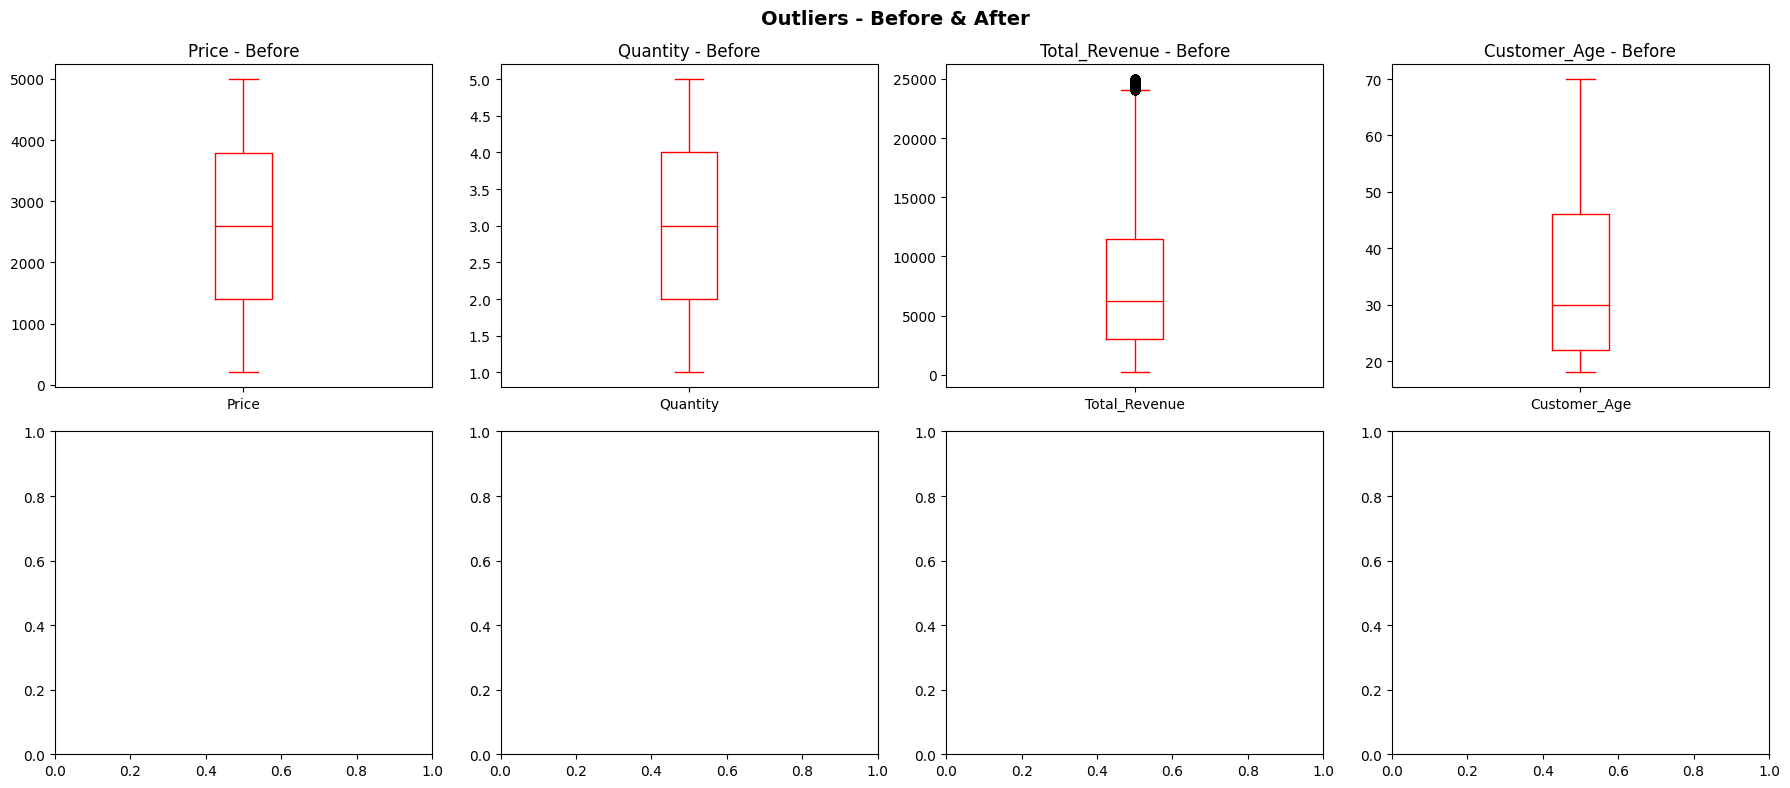

Price: Q1=1399.79, Q3=3795.98, IQR=2396.20, Outliers=0
Quantity: Q1=2.00, Q3=4.00, IQR=2.00, Outliers=0
Total_Revenue: Q1=3059.48, Q3=11472.16, IQR=8412.69, Outliers=764
Customer_Age: Q1=22.00, Q3=46.00, IQR=24.00, Outliers=0


In [44]:
# ============================================================
# 8. OUTLIERS - BEFORE
# ============================================================
num_cols = ['Price', 'Quantity', 'Total_Revenue', 'Customer_Age']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Outliers - Before & After', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    df[col].plot(kind='box', ax=axes[0, i], color='red')
    axes[0, i].set_title(f'{col} - Before')

plt.tight_layout()
plt.show()

# IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    print(f"{col}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, Outliers={outliers}")

Skewness:
Price           -0.000246
Quantity         0.000230
Total_Revenue    0.883493
Customer_Age    -0.002432
dtype: float64


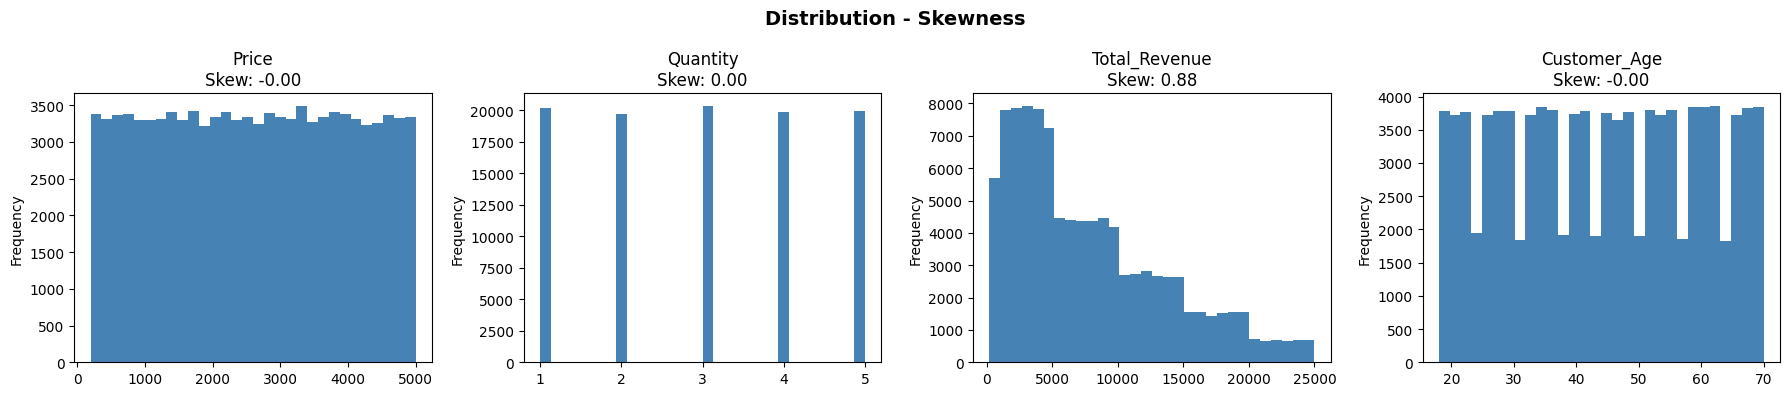

In [21]:
# ============================================================
# 9. SKEWNESS
# ============================================================
print("Skewness:")
print(df[num_cols].skew())

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle('Distribution - Skewness', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    df[col].plot(kind='hist', ax=axes[i], bins=30, color='steelblue')
    axes[i].set_title(f'{col}\nSkew: {df[col].skew():.2f}')

plt.tight_layout()
plt.show()

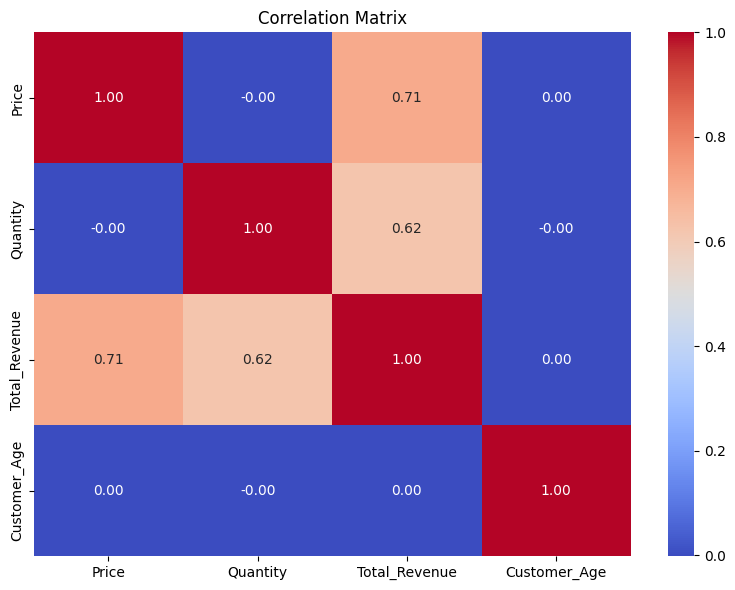

                  Price  Quantity  Total_Revenue  Customer_Age
Price          1.000000 -0.001376       0.705526      0.000136
Quantity      -0.001376  1.000000       0.624310     -0.000020
Total_Revenue  0.705526  0.624310       1.000000      0.000451
Customer_Age   0.000136 -0.000020       0.000451      1.000000


In [22]:
# ============================================================
# 10. CORRELATION
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6))

correlation = df[num_cols].corr()
sns.heatmap(correlation, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            ax=ax)
ax.set_title('Correlation Matrix')
plt.tight_layout()
plt.show()

print(correlation)

In [ ]:
df['Total_Revenue'].describe()

count    100000.000000
mean       7784.342350
std        5875.407773
min         200.050000
25%        3059.477500
50%        6216.120000
75%       11472.162500
max       24998.350000
Name: Total_Revenue, dtype: float64

In [25]:
# ============================================================
# 11. FEATURE ENGINEERING
# ============================================================

# Quarter
df['Quarter'] = df['Date'].dt.quarter.map({1:'Q1', 2:'Q2', 3:'Q3', 4:'Q4'})

# Season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)

# Revenue Category
Q1_rev = df['Total_Revenue'].quantile(0.25)
Q3_rev = df['Total_Revenue'].quantile(0.75)

df['Revenue_Category'] = pd.cut(df['Total_Revenue'],
                                  bins=[0, Q1_rev, Q3_rev, df['Total_Revenue'].max()],
                                  labels=['Low', 'Medium', 'High'])

print(df[['Total_Revenue', 'Quarter', 'Season', 'Revenue_Category']].head(10))
print("\nRevenue Category Distribution:")
print(df['Revenue_Category'].value_counts())

   Total_Revenue Quarter  Season Revenue_Category
0         318.32      Q3  Summer              Low
1       12373.88      Q2  Spring             High
2       12743.97      Q3    Fall             High
3        5166.03      Q3    Fall           Medium
4       11824.32      Q1  Winter             High
5        8890.60      Q3    Fall           Medium
6        6054.40      Q2  Summer           Medium
7        3825.94      Q3  Summer           Medium
8        1844.82      Q4    Fall              Low
9       13537.00      Q1  Spring             High

Revenue Category Distribution:
Revenue_Category
Medium    50000
Low       25000
High      25000
Name: count, dtype: int64


In [26]:
# ============================================================
# 12. NORMALIZATION
# ============================================================
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# نعمل copy للـ ML version
df_ml = df.copy()

scaler = MinMaxScaler()

num_cols = ['Price', 'Quantity', 'Total_Revenue', 'Customer_Age']

df_ml[num_cols] = scaler.fit_transform(df_ml[num_cols])

print("Before Normalization:")
print(df[num_cols].describe().round(2))
print("\nAfter Normalization:")
print(df_ml[num_cols].describe().round(2))

Before Normalization:
           Price   Quantity  Total_Revenue  Customer_Age
count  100000.00  100000.00      100000.00     100000.00
mean     2598.18       3.00        7784.34         44.04
std      1384.94       1.41        5875.41         15.31
min       200.01       1.00         200.05         18.00
25%      1399.79       2.00        3059.48         31.00
50%      2598.57       3.00        6216.12         44.00
75%      3795.98       4.00       11472.16         57.00
max      4999.81       5.00       24998.35         70.00

After Normalization:
           Price   Quantity  Total_Revenue  Customer_Age
count  100000.00  100000.00      100000.00     100000.00
mean        0.50       0.50           0.31          0.50
std         0.29       0.35           0.24          0.29
min         0.00       0.00           0.00          0.00
25%         0.25       0.25           0.12          0.25
50%         0.50       0.50           0.24          0.50
75%         0.75       0.75           0.45  

In [ ]:
# ============================================================
# 13. ENCODING
# ============================================================
from sklearn.preprocessing import LabelEncoder

# Label Encoding
label_cols = {
    'Age_Group': ['Youth', 'Adult', 'Middle Age', 'Senior'],
    'Revenue_Category': ['Low', 'Medium', 'High'],
    'Season': ['Spring', 'Summer', 'Fall', 'Winter'],
    'Quarter': ['Q1', 'Q2', 'Q3', 'Q4']
}

for col, order in label_cols.items():
    df_ml[col] = df_ml[col].map({v: i for i, v in enumerate(order)})

print("Label Encoding:")
print(df_ml[['Age_Group', 'Revenue_Category', 'Season', 'Quarter']].head())

# One Hot Encoding
ohe_cols = ['Bike_Model', 'Store_Location', 'Payment_Method']
df_ml = pd.get_dummies(df_ml, columns=ohe_cols)

print("\nShape after encoding:", df_ml.shape)
print("\nNew columns:", df_ml.columns.tolist())

Label Encoding:
  Age_Group Revenue_Category  Season  Quarter
0         3                0       1        2
1         1                2       0        1
2         2                2       2        2
3         0                1       2        2
4         3                2       3        0

Shape after encoding: (100000, 38)

New columns: ['Sale_ID', 'Date', 'Customer_ID', 'Price', 'Quantity', 'Salesperson_ID', 'Customer_Age', 'Total_Revenue', 'Year', 'Month', 'Month_Name', 'Day_of_Week', 'Age_Group', 'Quarter', 'Season', 'Revenue_Category', 'Bike_Model_BMX', 'Bike_Model_Cruiser', 'Bike_Model_Electric Bike', 'Bike_Model_Folding Bike', 'Bike_Model_Hybrid Bike', 'Bike_Model_Mountain Bike', 'Bike_Model_Road Bike', 'Store_Location_Chicago', 'Store_Location_Houston', 'Store_Location_Los Angeles', 'Store_Location_New York', 'Store_Location_Philadelphia', 'Store_Location_Phoenix', 'Store_Location_San Antonio', 'Payment_Method_Apple Pay', 'Payment_Method_Cash', 'Payment_Method_Credit Card', '

In [28]:
# Drop الكولمز الغلط
df_ml.drop(columns=['Customer_Gender_Female', 'Customer_Gender_Male'], inplace=True)

# Label Encoding للـ Gender
df_ml['Customer_Gender'] = df['Customer_Gender'].map({'Male': 0, 'Female': 1})

print("Gender Encoding:")
print(df_ml['Customer_Gender'].value_counts())
print("\nShape:", df_ml.shape)

Gender Encoding:
Customer_Gender
1    50227
0    49773
Name: count, dtype: int64

Shape: (100000, 37)


In [29]:
# ============================================================
# 14. SAVE
# ============================================================

# النسخة الأولى - SQL & Power BI
df.to_csv(r"D:\Study\Data Analysi_NTI\final project\dataset\bike_sales_cleaned.csv", index=False)
print("bike_sales_cleaned.csv saved!")

# النسخة التانية - ML Ready
df_ml.to_csv(r"D:\Study\Data Analysi_NTI\final project\dataset\bike_sales_ml_ready.csv", index=False)
print("bike_sales_ml_ready.csv saved!")

bike_sales_cleaned.csv saved!
bike_sales_ml_ready.csv saved!


In [30]:
# ============================================================
# Merge Salesperson Name
# ============================================================
dim_salesperson = pd.read_csv(r"D:\Study\Data Analysi_NTI\final project\dataset\dim_salesperson.csv")

df = df.merge(dim_salesperson, on='Salesperson_ID', how='left')

print(df[['Salesperson_ID', 'Salesperson_Name']].head())
print("\nShape:", df.shape)

   Salesperson_ID Salesperson_Name
0             589    Lance Simmons
1             390      David Smith
2             338    Sara Johnston
3             352        Tanya Kim
4             580     Dawn Mullins

Shape: (100000, 21)


In [32]:
df.to_csv(r"D:\Study\Data Analysi_NTI\final project\dataset\bike_sales_cleaned.csv", index=False)
print("bike_sales_cleaned.csv saved!")

# النسخة التانية - ML Ready
df_ml = df_ml.merge(dim_salesperson, on='Salesperson_ID', how='left')
df_ml.to_csv(r"D:\Study\Data Analysi_NTI\final project\dataset\bike_sales_ml_ready.csv", index=False)
print("bike_sales_ml_ready.csv saved!")

bike_sales_cleaned.csv saved!
bike_sales_ml_ready.csv saved!


In [ ]:
cols = ['Sale_ID', 'Date', 'Year', 'Month', 'Month_Name', 'Quarter', 
        'Season', 'Day_of_Week', 'Customer_ID', 'Customer_Age', 
        'Customer_Gender', 'Age_Group', 'Bike_Model', 'Price', 
        'Quantity', 'Total_Revenue', 'Revenue_Category', 
        'Store_Location', 'Salesperson_ID', 'Salesperson_Name', 
        'Payment_Method']
2
df = df[cols]
df.to_csv(r"D:\Study\Data Analysi_NTI\final project\dataset\bike_sales_cleaned.csv", index=False)
print("Saved!")
print(df.columns.tolist())

Saved!
['Sale_ID', 'Date', 'Year', 'Month', 'Month_Name', 'Quarter', 'Season', 'Day_of_Week', 'Customer_ID', 'Customer_Age', 'Customer_Gender', 'Age_Group', 'Bike_Model', 'Price', 'Quantity', 'Total_Revenue', 'Revenue_Category', 'Store_Location', 'Salesperson_ID', 'Salesperson_Name', 'Payment_Method']


In [36]:
# تحقق من المشكلة
customer_dupes = df.groupby('Customer_ID')[['Customer_Age', 'Customer_Gender']].nunique()
print(customer_dupes[customer_dupes['Customer_Age'] > 1].head(10))
print(customer_dupes[customer_dupes['Customer_Gender'] > 1].head(10))

             Customer_Age  Customer_Gender
Customer_ID                               
1000                   10                2
1001                    6                2
1002                   12                2
1003                   11                2
1004                    8                2
1005                    9                2
1006                   14                2
1007                   10                2
1008                    6                2
1009                   11                2
             Customer_Age  Customer_Gender
Customer_ID                               
1000                   10                2
1001                    6                2
1002                   12                2
1003                   11                2
1004                    8                2
1005                    9                2
1006                   14                2
1007                   10                2
1008                    6                2
1009       

In [37]:
# ناخد الـ mode لكل Customer_ID
customer_fixed = df.groupby('Customer_ID').agg(
    Customer_Age=('Customer_Age', lambda x: x.mode()[0]),
    Customer_Gender=('Customer_Gender', lambda x: x.mode()[0]),
    Age_Group=('Age_Group', lambda x: x.mode()[0])
).reset_index()

# نعمل drop للكولمز دي من الـ df الأصلي
df = df.drop(columns=['Customer_Age', 'Customer_Gender', 'Age_Group'])

# نعمل merge تاني بالقيم الثابتة
df = df.merge(customer_fixed, on='Customer_ID', how='left')

print(df.groupby('Customer_ID')[['Customer_Age', 'Customer_Gender']].nunique().max())

Customer_Age       1
Customer_Gender    1
dtype: int64


In [39]:
# إعادة حساب Age_Group
df['Age_Group'] = pd.cut(df['Customer_Age'],
                          bins=[0, 25, 40, 60, 100],
                          labels=['Youth', 'Adult', 'Middle Age', 'Senior'])

# إعادة ترتيب الكولمز
df = df[cols]

# حفظ
df.to_csv(r"D:\Study\Data Analysi_NTI\final project\dataset\bike_sales_cleaned.csv", index=False)
print("Saved!")

Saved!


In [40]:
# نعيد عمل df_ml من الأول
df_ml = df.copy()

# Normalization
df_ml[num_cols] = scaler.fit_transform(df_ml[num_cols])

# Label Encoding
label_cols_map = {
    'Age_Group': ['Youth', 'Adult', 'Middle Age', 'Senior'],
    'Revenue_Category': ['Low', 'Medium', 'High'],
    'Season': ['Spring', 'Summer', 'Fall', 'Winter'],
    'Quarter': ['Q1', 'Q2', 'Q3', 'Q4'],
    'Customer_Gender': ['Male', 'Female']
}

for col, order in label_cols_map.items():
    df_ml[col] = df_ml[col].map({v: i for i, v in enumerate(order)})

# One Hot Encoding
ohe_cols = ['Bike_Model', 'Store_Location', 'Payment_Method']
df_ml = pd.get_dummies(df_ml, columns=ohe_cols)

# حفظ
df_ml.to_csv(r"D:\Study\Data Analysi_NTI\final project\dataset\bike_sales_ml_ready.csv", index=False)
print("Saved!")
print("Shape:", df_ml.shape)

Saved!
Shape: (100000, 38)


In [45]:
# نشوف كل الـ categorical columns فيها مشكلة
for col in ['Bike_Model', 'Store_Location', 'Payment_Method', 'Salesperson_Name']:
    counts = df.groupby('Customer_ID')[col].nunique()
    print(f"{col}: max unique per customer = {counts.max()}")

Bike_Model: max unique per customer = 7
Store_Location: max unique per customer = 7
Payment_Method: max unique per customer = 6
Salesperson_Name: max unique per customer = 27


In [46]:
import pandas as pd

# نقرا من SQL ونصدر Excel
import pyodbc

conn = pyodbc.connect('DRIVER={SQL Server};SERVER=.;DATABASE=BikeStoreDB;Trusted_Connection=yes')

tables = ['fact_sales', 'dim_date', 'dim_customer', 'dim_bike', 'dim_store', 'dim_payment', 'dim_salesperson']

with pd.ExcelWriter(r"D:\Study\Data Analysi_NTI\final project\dataset\bike_sales_DWH.xlsx") as writer:
    for table in tables:
        df_temp = pd.read_sql(f"SELECT * FROM {table}", conn)
        df_temp.to_excel(writer, sheet_name=table, index=False)

print("Exported!")

C:\Users\Memo\AppData\Local\Temp\ipykernel_14696\3088841687.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_temp = pd.read_sql(f"SELECT * FROM {table}", conn)


Exported!
